### Prediccion de precios de viviendas con XGBoost

Objetivo: Realizar una exploración incial del dataset de viviendas y entrenar el modelo de regresión usando XGBoost para predecir el precio estimado de una vivienda en pesos mexicanos 

In [3]:
# Importar librerias necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from  sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
import warnings 
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("dataset_viviendas_mexico.csv")
df.head()

,tamaño_m2,habitaciones,baños,estacionamientos,antigüedad_años,zona,cercania_transporte,precio_miles_mxn
0,92.4,2,2,0,39,Centro,Alta,1852.06
1,76.5,2,2,0,16,Centro,Alta,1901.57
2,96.2,3,1,0,36,Residencial,Baja,1465.81
3,118.1,3,3,2,38,Periferia,Media,1971.69
4,74.1,5,3,0,28,Residencial,Alta,1955.77


In [5]:
#!pip install xgboost

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   tamaño_m2            500 non-null    float64
 1   habitaciones         500 non-null    int64  
 2   baños                500 non-null    int64  
 3   estacionamientos     500 non-null    int64  
 4   antigüedad_años      500 non-null    int64  
 5   zona                 500 non-null    object 
 6   cercania_transporte  500 non-null    object 
 7   precio_miles_mxn     500 non-null    float64
dtypes: float64(2), int64(4), object(2)
memory usage: 31.4+ KB


## Analisis exploratorio 

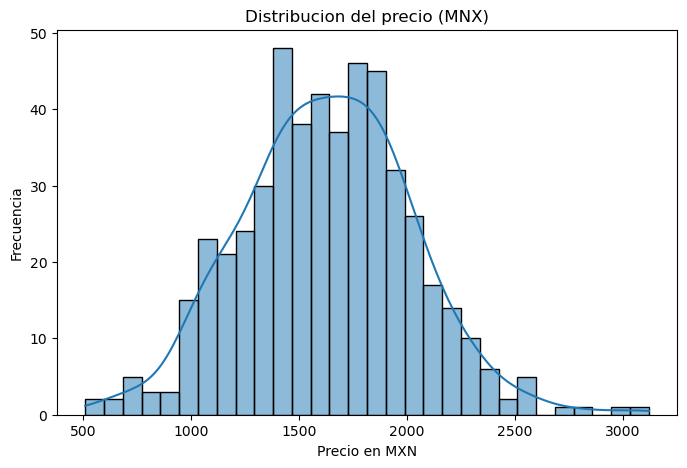

In [8]:
# Visualizar la distribucion del precio
plt.figure(figsize=(8,5))
sns.histplot(df["precio_miles_mxn"], kde=True, bins=30)
plt.title("Distribucion del precio (MNX)")
plt.xlabel("Precio en MXN")
plt.ylabel("Frecuencia")
plt.show() 

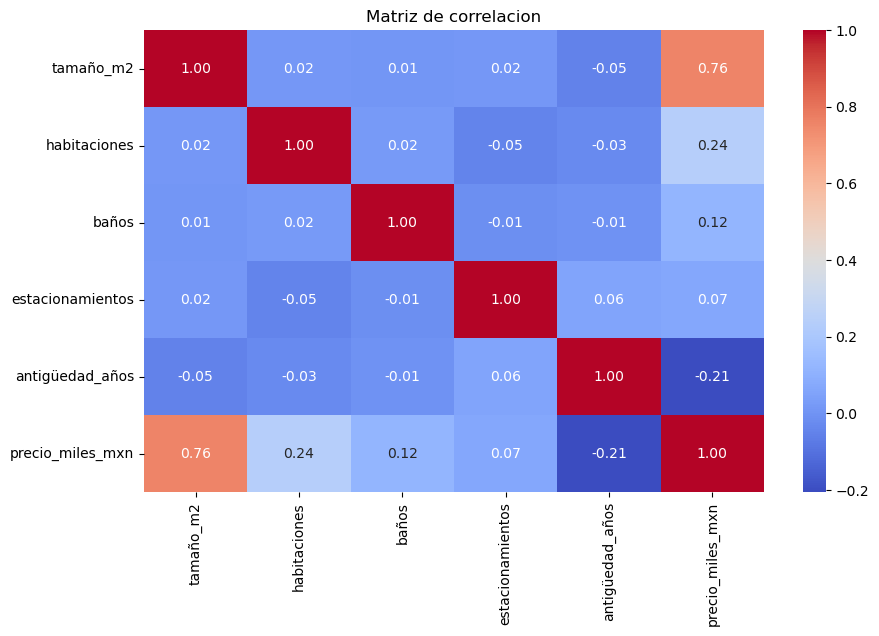

In [9]:
# Analizar correlacion entre variable numericas
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlacion")
plt.show() 

## Preprocesamiento 

In [11]:
# codificar variables categoricas con numeros
df["zona_cod"] = df["zona"].map({"Centro": 3, "Residencial":2, "Periferia":1, "Industrial":0})
df["transporte_cod"]  = df["cercania_transporte"].map({"Alta":2, "Media": 1, "Baja":0})


## Crear el modelo 

In [13]:
# X = Variables predictoras
X = df[["tamaño_m2", "habitaciones", "baños","estacionamientos","antigüedad_años","zona_cod","transporte_cod"]]

# Y = Variable objetivo (Precio de una vivienda)
Y = df["precio_miles_mxn"]

In [14]:
# Dividir datos en conjunto de entrenamiento y prueba
x_train, x_test, y_train, y_test = train_test_split(X,Y, test_size=0.2, random_state=42) 


In [15]:
x_train

,tamaño_m2,habitaciones,baños,estacionamientos,antigüedad_años,zona_cod,transporte_cod
249,90.1,1,3,0,3,3,2
433,97.9,5,2,1,17,1,2
19,44.7,4,1,0,4,2,0
322,59.5,2,1,1,45,2,1
332,81.9,2,1,2,18,1,1
...,...,...,...,...,...,...,...
106,127.2,3,3,0,4,1,1
270,116.0,1,1,1,41,2,2
348,62.0,5,2,0,3,1,1
435,81.9,2,2,1,20,1,2


In [16]:
y_train

249    1973.34
433    2034.27
19     1075.70
322    1294.46
332    1502.98
        ...   
106    2193.31
270    1921.35
348    1381.09
435    1715.55
102    1002.87
Name: precio_miles_mxn, Length: 400, dtype: float64

In [17]:
# Entrenar el modelo
modelo = xgb.XGBRegressor(n_estimators=100, random_state=42)
modelo.fit(x_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

## Evaluar el desempeño del modelo 

In [19]:
y_pred = modelo.predict(x_test)

In [20]:
y_pred

array([2285.3806 , 1710.3177 , 2053.3203 , 1435.701  , 1886.9913 ,
       1984.3413 , 1525.4573 , 1915.3396 , 1582.5985 , 1292.1265 ,
       1739.4917 , 1661.9369 , 1353.1863 , 1275.2188 , 1797.506  ,
       2320.7139 , 1829.4414 , 1446.9961 , 1915.5709 , 1348.4069 ,
       1548.5363 , 2297.3955 , 1608.958  , 1823.8685 , 1730.3529 ,
       1666.2809 , 1480.6982 , 1851.6716 , 1079.9788 , 1790.6714 ,
       2083.656  , 1270.4144 , 1437.5652 , 1741.6392 , 1753.5608 ,
       1781.1344 , 1946.8857 , 1914.4918 , 3002.63   ,  971.44476,
       1084.1097 , 1699.0183 , 1170.5613 , 1774.5449 , 1238.4474 ,
       1513.2426 , 1891.5648 , 1433.5864 , 1136.5862 , 1410.9679 ,
       1578.8455 ,  952.3338 , 1467.137  , 1727.588  , 1361.5607 ,
       1886.8972 , 2012.8386 , 1660.8849 ,  990.8885 , 2045.0695 ,
       2313.9092 , 1295.8494 , 2089.807  , 1932.1053 , 1482.9545 ,
       1918.8501 , 1965.2445 , 1487.0088 , 1377.1248 , 1683.3125 ,
       1790.266  , 1451.5923 , 1785.9443 , 1462.4781 , 1168.59

In [21]:
y_test

361    2430.19
73     1871.41
374    2243.82
155    1660.01
104    2018.57
        ...   
347    1456.23
86     1701.70
75     1787.36
438     710.97
15     1952.16
Name: precio_miles_mxn, Length: 100, dtype: float64

In [22]:
# Mostrar metricas de error
print("MSE:", mean_squared_error(y_test,y_pred)) # Error cuadratico medio
print("R2:", r2_score(y_test,y_pred)) # Coeficiente de determinacion 

MSE: 22255.043055175305
R2: 0.8518600021924485


In [23]:
# Crear un nuevo registro para predecir 
nuevo = pd.DataFrame({
    "tamaño_m2": [95],
    "habitaciones": [3],
    "baños": [1],
    "estacionamientos": [1],
    "antigüedad_años": [10],
    "zona_cod": [3], # Zona centro
    "transporte_cod": [2] # Alta
})

In [24]:
# predecir el precio del modelo entrenado
precio_estimado = modelo.predict(nuevo)[0]
print(f"precio estimado: ${precio_estimado:.2f} MXN")

precio estimado: $2129.17 MXN


## Encontrar el mejor numero de Arboles

In [69]:

# Dividir el conjunto de entrenamiento en train/validación
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    x_train, y_train, test_size=0.2, random_state=42
)
dtrain = xgb.DMatrix(X_train_split, label=y_train_split)
dvalid = xgb.DMatrix(X_val_split, label=y_val_split)
dtest = xgb.DMatrix(x_test)

In [57]:
# Parametro del modelos
params ={"eval_metric": "rmse", "seed": 42}


In [59]:
#conjunto de evaluacion
avals =[(dtrain,"train"), (dvalid,"eval")]

In [61]:
mejor_rmse = float("inf")

In [65]:
#variable para guardar el mejor modelo encontrado
modelo_early = None

In [71]:
# early_stopping_rounds
for stop in [5, 10, 20,50]:
    modelo = xgb.train(
        params=params,                       # Diccionario con los parámetros del modelo
        dtrain=dtrain,                       # Conjunto de entrenamiento en formato DMatrix
        num_boost_round=1000,                # Número máximo de árboles que puede entrenar
        evals=[(dvalid, "eval")],            # Validación en cada iteración para aplicar early stopping
        early_stopping_rounds=stop,          # Número de iteraciones sin mejora antes de detenerse
        verbose_eval=False                   # No mostrar información en cada iteración
    )
    y_pred = modelo.predict(dtest)
    rmse = mean_squared_error(y_test, y_pred, squared= False)
    print(f"Detener ={stop}  Mejor Iteracion: {modelo.best_iteration}, RMSE: {rmse:.2f}") # Error cuadratico medio
    # Evaluar si este modelo es el mejor hasta ahora
    if rmse < mejor_rmse:
        mejor_rmse=rmse
        modelo_early = modelo
        y_pred_early = y_pred
print("Mejor configuracion encontrada")
print("Mejor numero de árboles:", modelo_early.best_iteration)
print(f"Mejor RMSE en test: {mejor_rmse:.2f}")


Detener =5  Mejor Iteracion: 21, RMSE: 147.54
Detener =10  Mejor Iteracion: 21, RMSE: 148.51
Detener =20  Mejor Iteracion: 21, RMSE: 149.38
Detener =50  Mejor Iteracion: 21, RMSE: 150.67
Mejor configuracion encontrada
Mejor numero de árboles: 21
Mejor RMSE en test: 147.54
